In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("ML libraries loaded successfully!")

ML libraries loaded successfully!


In [2]:
DATA_PATH = "../data/processed/pune_traffic_intelligent.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded!
Shape: (9736, 13)


,time,direction,car_count,bike_count,bus_count,truck_count,total_vehicles,intersection,camera,source_file,traffic_level,traffic_pressure,recommended_green
0,1900-01-01 08:55:00,DOWN,1.0,0.0,0.0,0.0,1.0,JehangirChowk,j1,j1_12.csv,LOW,1.0,15
1,1900-01-01 08:55:00,LEFT,1.0,0.0,0.0,0.0,1.0,JehangirChowk,j1,j1_12.csv,LOW,1.0,15
2,1900-01-01 08:55:00,RIGHT,0.0,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv,LOW,0.0,15
3,1900-01-01 08:55:00,UP,0.0,0.0,0.0,0.0,0.0,JehangirChowk,j1,j1_12.csv,LOW,0.0,15
4,1900-01-01 09:00:00,DOWN,77.0,122.0,3.0,10.0,212.0,JehangirChowk,j1,j1_12.csv,VERY_HIGH,175.5,60


In [3]:
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

['time', 'direction', 'car_count', 'bike_count', 'bus_count', 'truck_count', 'total_vehicles', 'intersection', 'camera', 'source_file', 'traffic_level', 'traffic_pressure', 'recommended_green']

Missing values:
time                 0
direction            0
car_count            0
bike_count           0
bus_count            0
truck_count          0
total_vehicles       0
intersection         0
camera               0
source_file          0
traffic_level        0
traffic_pressure     0
recommended_green    0
dtype: int64


In [4]:
df["time"] = pd.to_datetime(df["time"], errors="coerce")

df["hour"] = df["time"].dt.hour
df["minute"] = df["time"].dt.minute

display(
    df[
        ["time", "hour", "minute", "total_vehicles"]
    ].head(10)
)

,time,hour,minute,total_vehicles
0,1900-01-01 08:55:00,8,55,1.0
1,1900-01-01 08:55:00,8,55,1.0
2,1900-01-01 08:55:00,8,55,0.0
3,1900-01-01 08:55:00,8,55,0.0
4,1900-01-01 09:00:00,9,0,212.0
5,1900-01-01 09:00:00,9,0,59.0
6,1900-01-01 09:00:00,9,0,57.0
7,1900-01-01 09:00:00,9,0,4.0
8,1900-01-01 09:05:00,9,5,246.0
9,1900-01-01 09:05:00,9,5,44.0


In [5]:
df["recording_id"] = (
    df["intersection"].astype(str)
    + "_"
    + df["camera"].astype(str)
    + "_"
    + df["source_file"].astype(str)
)

print("Recordings:", df["recording_id"].nunique())

Recordings: 115


In [6]:
df = df.sort_values(
    [
        "recording_id",
        "direction",
        "time"
    ]
).reset_index(drop=True)

In [7]:
group_cols = [
    "recording_id",
    "direction"
]

df["lag_1"] = (
    df.groupby(group_cols)["total_vehicles"]
    .shift(1)
)

df["lag_2"] = (
    df.groupby(group_cols)["total_vehicles"]
    .shift(2)
)

df["lag_3"] = (
    df.groupby(group_cols)["total_vehicles"]
    .shift(3)
)

In [8]:
df["rolling_mean_3"] = (
    df.groupby(group_cols)["total_vehicles"]
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)

In [9]:
df["target_next_5min"] = (
    df.groupby(group_cols)["total_vehicles"]
    .shift(-1)
)

In [10]:
features = [
    "hour",
    "minute",
    "total_vehicles",
    "traffic_pressure",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3"
]

target = "target_next_5min"

ml_df = df.dropna(
    subset=features + [target]
).copy()

print("ML-ready rows:", len(ml_df))

display(
    ml_df[
        features + [target]
    ].head(10)
)

ML-ready rows: 7896


,hour,minute,total_vehicles,traffic_pressure,lag_1,lag_2,lag_3,rolling_mean_3,target_next_5min
3,9,15,14.0,18.5,12.0,17.0,7.0,12.000000,13.0
4,9,20,13.0,16.5,14.0,12.0,17.0,14.333333,12.0
5,9,25,12.0,14.5,13.0,14.0,12.0,13.000000,11.0
6,9,30,11.0,19.0,12.0,13.0,14.0,13.000000,14.0
7,9,35,14.0,26.0,11.0,12.0,13.0,12.000000,17.0
8,9,40,17.0,19.5,14.0,11.0,12.0,12.333333,11.0
9,9,45,11.0,9.0,17.0,14.0,11.0,14.000000,20.0
10,9,50,20.0,27.0,11.0,17.0,14.0,14.000000,16.0
11,9,55,16.0,21.0,20.0,11.0,17.0,16.000000,10.0
12,10,0,10.0,12.0,16.0,20.0,11.0,15.666667,18.0


In [11]:
ml_df = ml_df.sort_values(
    ["recording_id", "direction", "time"]
).reset_index(drop=True)

split_index = int(len(ml_df) * 0.80)

train_df = ml_df.iloc[:split_index]
test_df = ml_df.iloc[split_index:]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 6316
Testing rows: 1580


In [12]:
baseline_predictions = test_df["total_vehicles"]

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

print("BASELINE")
print("MAE :", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))

BASELINE
MAE : 8.69
RMSE: 16.32


In [13]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [14]:
predictions = rf_model.predict(X_test)

predictions = np.maximum(
    predictions,
    0
)

print("Predictions generated!")

Predictions generated!


In [15]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("RANDOM FOREST RESULTS")
print("---------------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 3))

RANDOM FOREST RESULTS
---------------------
MAE : 7.47
RMSE: 13.9
R²  : 0.936


In [16]:
comparison = pd.DataFrame({
    "Model": [
        "Persistence Baseline",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        mae
    ],
    "RMSE": [
        baseline_rmse,
        rmse
    ]
})

display(comparison)

,Model,MAE,RMSE
0,Persistence Baseline,8.692405,16.318585
1,Random Forest,7.470838,13.904096


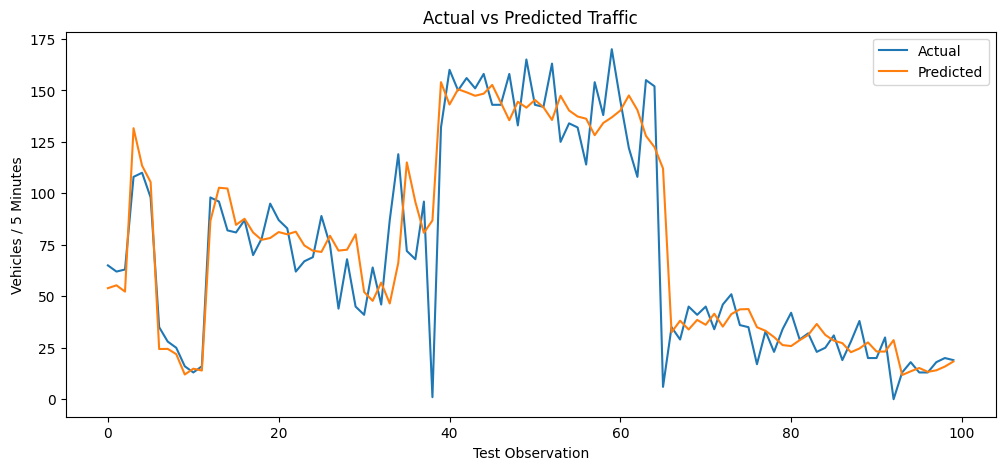

In [17]:
results = test_df[
    [
        "time",
        "intersection",
        "direction",
        "target_next_5min"
    ]
].copy()

results["predicted_traffic"] = predictions

plot_data = results.head(100)

plt.figure(figsize=(12, 5))

plt.plot(
    range(len(plot_data)),
    plot_data["target_next_5min"],
    label="Actual"
)

plt.plot(
    range(len(plot_data)),
    plot_data["predicted_traffic"],
    label="Predicted"
)

plt.title("Actual vs Predicted Traffic")
plt.xlabel("Test Observation")
plt.ylabel("Vehicles / 5 Minutes")
plt.legend()

plt.show()

rolling_mean_3      0.380772
total_vehicles      0.351952
lag_2               0.071268
lag_1               0.059909
traffic_pressure    0.057814
lag_3               0.042840
minute              0.023427
hour                0.012018
dtype: float64

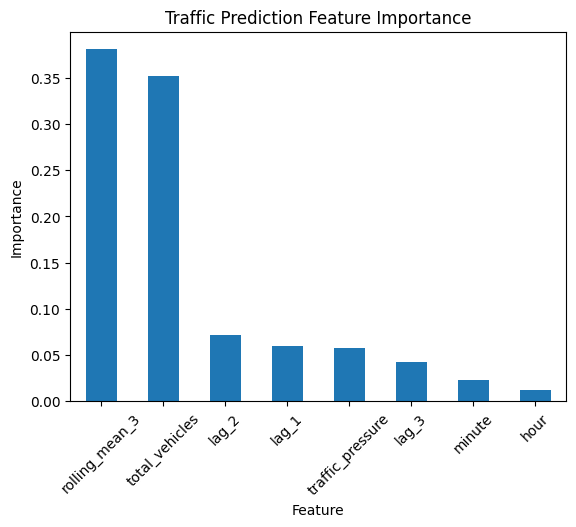

In [18]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

display(importance)

importance.plot(kind="bar")

plt.title("Traffic Prediction Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.show()

In [19]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(
    rf_model,
    MODEL_DIR / "traffic_random_forest.joblib"
)

print("Model saved successfully!")

Model saved successfully!


In [20]:
results.to_csv(
    "../data/processed/traffic_predictions.csv",
    index=False
)

print("Predictions saved!")

Predictions saved!
